
# Data Science with Databricks

## ML is key to wind turbine farm optimization

The current market makes energy even more strategic than before. Being able to ingest and analyze our Wind turbine state is a first step, but this isn't enough to thrive in a very competitive market.

We need to go further to optimize our energy production, reduce maintenance cost and reduce downtime. Modern data company achieve this with AI.

<style>
.right_box{
  margin: 30px; box-shadow: 10px -10px #CCC; width:650px;height:300px; background-color: #1b3139ff; box-shadow:  0 0 10px  rgba(0,0,0,0.6);
  border-radius:25px;font-size: 35px; float: left; padding: 20px; color: #f9f7f4; }
.badge {
  clear: left; float: left; height: 30px; width: 30px;  display: table-cell; vertical-align: middle; border-radius: 50%; background: #fcba33ff; text-align: center; color: white; margin-right: 10px}
.badge_b { 
  height: 35px}
</style>
<link href='https://fonts.googleapis.com/css?family=DM Sans' rel='stylesheet'>
<div style="font-family: 'DM Sans'; display: flex; align-items: flex-start;">
  <!-- Left Section -->
  <div style="width: 50%; color: #1b3139; padding-right: 20px;">
    <div style="color: #ff5f46; font-size:80px;">90%</div>
    <div style="font-size:30px; margin-top: -20px; line-height: 30px;">
      Enterprise applications will be AI-augmented by 2025 —IDC
    </div>
    <div style="color: #ff5f46; font-size:80px;">$10T+</div>
    <div style="font-size:30px; margin-top: -20px; line-height: 30px;">
       Projected business value creation by AI in 2030 —PWC
    </div>
  </div>

  <!-- Right Section -->
  <div class="right_box", style="width: 50%; color: red; font-size: 30px; line-height: 1.5; padding-left: 20px;">
    But—huge challenges getting ML to work at scale!<br/><br/>
    In fact, most ML projects still fail before getting to production
  </div>
</div>

## Machine learning is data + transforms.

ML is hard because delivering value to business lines isn't only about building a Model. <br>
The ML lifecycle is made of data pipelines: Data-preprocessing, feature engineering, training, inference, monitoring and retraining...<br>
Stepping back, all pipelines are data + code.


<img style="float: right; margin-top: 10px" width="500px" src="https://raw.githubusercontent.com/databricks-demos/dbdemos-resources/refs/heads/main/images/manufacturing/lakehouse-iot-turbine/team_flow_marc.png" />

<img src="https://raw.githubusercontent.com/databricks-demos/dbdemos-resources/refs/heads/main/images/marc.png" style="float: left;" width="80px"> 
<h3 style="padding: 10px 0px 0px 5px">Marc, as a Data Scientist, needs a data + ML platform accelerating all the ML & DS steps:</h3>

<div style="font-size: 19px; margin-left: 73px; clear: left">
<div class="badge_b"><div class="badge">1</div> Build Data Pipeline supporting real time (with SDP)</div>
<div class="badge_b"><div class="badge">2</div> Data Exploration</div>
<div class="badge_b"><div class="badge">3</div> Feature creation</div>
<div class="badge_b"><div class="badge">4</div> Build & train model</div>
<div class="badge_b"><div class="badge">5</div> Deploy Model (Batch or serverless realtime)</div>
<div class="badge_b"><div class="badge">6</div> Monitoring</div>
</div>

**Marc needs a Data Intelligence Platform**. Let's see how we can deploy a Predictive Maintenance model in production with Databricks.


# Predictive maintenance - Single click deployment with AutoML

Let's see how we can now leverage the sensor data to build a model predictive maintenance model.

Our first step as Data Scientist is to analyze and build the features we'll use to train our model.

The sensor table enriched with turbine data has been saved within our Spark Declarative Pipelines pipeline. All we have to do is read this information, analyze it and start an Auto-ML run.

<img src="https://github.com/databricks-demos/dbdemos-resources/raw/main/images/manufacturing/lakehouse-iot-turbine/lakehouse-manuf-iot-ds-flow.png" width="1000px">

*Note: Make sure you switched to the "Machine Learning" persona on the top left menu.*


<!-- Collect usage data (view). Remove it to disable collection. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F04-Data-Science-ML%2F04.1-automl-iot-turbine-predictive-maintenance&demo_name=lakehouse-iot-platform&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-iot-platform%2F04-Data-Science-ML%2F04.1-automl-iot-turbine-predictive-maintenance&version=1">

In [0]:
%pip install --quiet databricks-sdk==0.59.0 mlflow==3.1.1 databricks-feature-engineering==0.12.1
dbutils.library.restartPython()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.21 requires langchain-core<1.0.0,>=0.3.45, but you have langchain-core 1.0.1 which is incompatible.
langchain 0.3.21 requires langsmith<0.4,>=0.1.17, but you have langsmith 0.4.38 which is incompatible.
langchain-text-splitters 0.3.8 requires langchain-core<1.0.0,>=0.3.51, but you have langchain-core 1.0.1 which is incompatible.
tensorboard 2.17.0 requires protobuf!=4.24.0,<5.0.0,>=3.19.6, but you have protobuf 5.29.5 which is incompatible.
tensorboard-plugin-profile 2.17.0 requires protobuf<5.0.0dev,>=3.19.6, but you have protobuf 5.29.5 which is incompatible.
tensorflow 2.17.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.5 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.

In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main_build`
using catalog.database `main_build`.`dbdemos_iot_platform`


data already existing. Run with reset_all_data=true to force a data cleanup for your local demo.


## Data exploration and analysis

Let's review our dataset and start analyze the data we have to predict our churn

In [0]:
def plot(sensor_report):
  turbine_id = spark.table('turbine_training_dataset').where(f"abnormal_sensor = '{sensor_report}' ").limit(1).collect()[0]['turbine_id']
  #Let's explore a bit our datasets with pandas on spark.
  df = spark.table('sensor_bronze').where(f"turbine_id == '{turbine_id}' ").orderBy('timestamp').limit(500).pandas_api()
  df.plot(x="timestamp", y=["sensor_B"], kind="line", title=f'Sensor report: {sensor_report}').show()
plot('ok')

In [0]:
plot('sensor_B')

As we can see in these graph, we can clearly see some anomaly on the readings we get from sensor F. Let's continue our exploration and use the std we computed in our main feature table

In [0]:
# Read our churn_features table
turbine_dataset = spark.table('turbine_training_dataset').withColumn('damaged', col('abnormal_sensor') != 'ok')
display(turbine_dataset)

composite_key,sensor_vector,hourly_timestamp,avg_energy,std_sensor_A,std_sensor_B,std_sensor_C,std_sensor_D,std_sensor_E,std_sensor_F,percentiles_sensor_A,percentiles_sensor_B,percentiles_sensor_C,percentiles_sensor_D,percentiles_sensor_E,percentiles_sensor_F,country,lat,location,long,model,state,abnormal_sensor,end_time,maintenance_report,start_time,turbine_id,damaged
0102fe7c-5c53-73e0-8af3-36bb0d6ed3c5-1705423883,"List(1.0317488004915993, 4.16750575712864, 3.006398888665695, 2.1707802827557625, 2.4000319737945093, 2.1116362066875998)",2024-01-16T17:00:00Z,0.07840219544328246,1.0317488004915993,4.16750575712864,3.006398888665695,2.1707802827557625,2.4000319737945093,2.1116362066875998,"List(-2.405857400440471, -1.5509669282171377, -0.7908347168213696, -0.18850875297233405, 0.6325762551366425)","List(-4.795528997803453, -2.4354113947852856, -0.4805931765235357, 1.1898271965191176, 3.8832607905868333)","List(-4.899251361670518, -2.423173411468824, -0.06954980390192933, 1.6667351400881456, 3.7674946283135577)","List(-3.0788816355815314, -1.5003055883422682, 0.22683662825322948, 1.5776229487425346, 3.204189326889199)","List(-1.8367422266910256, 0.2429095431238024, 1.7485022528864875, 3.169469756843189, 4.8134322862159875)","List(-2.6764488788676397, -1.7458633079589043, -0.14882134863251104, 1.36831473103997, 3.1296979832822878)",US,39.00622,Sterling,-77.4286,EpicWind,America/New_York,sensor_B,1708017895,"Issue: Vibration in drivetrain components Root Cause: Misalignment, bearing wear, gearbox issues, or unbalanced rotor assemblies, leading to excessive vibration levels in drivetrain components during turbine operation. Solution: Perform vibration analysis and diagnostic tests on drivetrain components, including gearboxes, shafts, and bearings, to identify root causes of vibration problems. Rectify misalignment issues, replace worn-out bearings, and conduct dynamic balancing of rotor assemblies to reduce vibration levels and prevent damage to critical components. Implement condition monitoring systems equipped with accelerometers and vibration sensors to continuously monitor drivetrain performance and detect abnormal vibration patterns. Develop maintenance schedules for regular lubrication, alignment checks, and vibration analysis to ensure smooth and reliable operation of turbine drivetrains.",1705423883,0102fe7c-5c53-73e0-8af3-36bb0d6ed3c5,true
079c4b70-2dc1-c0fd-8d7c-5848a9bb9ca1-1705423244,"List(1.0837452523480138, 2.360860997259339, 3.2660960734353597, 7.660954988374002, 2.413765682518696, 1.88143485011735)",2024-01-16T17:00:00Z,0.3941072026023123,1.0837452523480138,2.360860997259339,3.2660960734353597,7.660954988374002,2.413765682518696,1.88143485011735,"List(-2.2889315550383627, -1.4997332121432423, -0.6744406224405927, -0.04521918787999912, 0.7967169977476469)","List(-3.873339147693613, -2.356876534517684, -0.6452454791958997, 0.6839325692894065, 2.454616518883495)","List(-5.102328786706246, -2.90991112696215, -0.7001800700031329, 1.1950080747188627, 4.153546074286979)","List(-5.643233913378216, -2.441456731796846, 0.79264047779302, 2.8246496078379963, 5.952752178674025)","List(-1.7396509756279728, -0.11729376379521916, 1.7675934187174416, 2.9192570085852494, 4.892622568722848)","List(-2.705924411959944, -1.7310009811591218, -0.0063375771246863, 1.2973070002525402, 2.671881697987927)",US,31.84568,Odessa,-102.36764,EpicWind,America/Chicago,sensor_D,1708018825,"Issue: Blade delamination Root Cause: Material degradation, bonding failure, or manufacturing defects in composite blade structures, leading to separation or delamination of laminate layers. Solution: Conduct detailed non-destructive testing, such as ultrasonic or thermographic inspections, to assess the extent of delamination and identify underlying causes. Repair delaminated blade sections using composite patching materials or adhesive bonding techniques to restore structural integrity. Implement quality control measures, such as improved manufacturing processes o

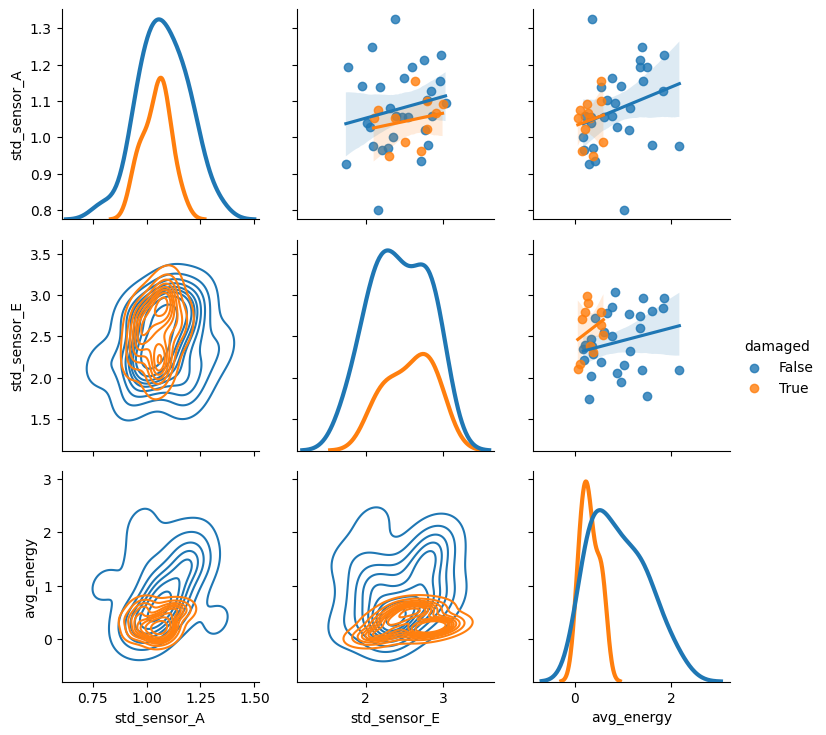

In [0]:
import seaborn as sns
g = sns.PairGrid(turbine_dataset.sample(0.01).toPandas()[['std_sensor_A', 'std_sensor_E', 'damaged','avg_energy']], diag_sharey=False, hue="damaged")
g.map_lower(sns.kdeplot).map_diag(sns.kdeplot, lw=3).map_upper(sns.regplot).add_legend()

### Further data analysis and preparation using pandas API

Because our Data Scientist team is familiar with Pandas, we'll use `pandas on spark` to scale `pandas` code. The Pandas instructions will be converted in the spark engine under the hood and distributed at scale.

Typicaly Data Science project would involve more advanced preparation and likely require extra data prep step, including more complex feature preparation. We'll keep it simple for this demo.

*Note: Starting from `spark 3.2`, koalas is builtin and we can get an Pandas Dataframe using `pandas_api()`.*

In [0]:
 # Convert to pandas (koalas)
dataset = turbine_dataset.pandas_api()

# Select the columns we would like to use as ML Model features. #Note: we removed percentiles_sensor_A/B/C.. feature to make the demo easier
columns = [
    "turbine_id",
    "hourly_timestamp",
    "avg_energy",
    "std_sensor_A",
    "std_sensor_B",
    "std_sensor_C",
    "std_sensor_D",
    "std_sensor_E",
    "std_sensor_F",
    "location",
    "model",
    "state",
    "abnormal_sensor"
]
dataset = dataset[columns]

# Drop missing values
dataset = dataset.dropna()   
display(dataset)

turbine_id,hourly_timestamp,avg_energy,std_sensor_A,std_sensor_B,std_sensor_C,std_sensor_D,std_sensor_E,std_sensor_F,location,model,state,abnormal_sensor
0102fe7c-5c53-73e0-8af3-36bb0d6ed3c5,2024-01-16T17:00:00Z,0.07840219544328246,1.0317488004915993,4.16750575712864,3.006398888665695,2.1707802827557625,2.4000319737945093,2.1116362066875998,Sterling,EpicWind,America/New_York,sensor_B
079c4b70-2dc1-c0fd-8d7c-5848a9bb9ca1,2024-01-16T17:00:00Z,0.3941072026023123,1.0837452523480138,2.360860997259339,3.2660960734353597,7.660954988374002,2.413765682518696,1.88143485011735,Odessa,EpicWind,America/Chicago,sensor_D
08beead8-8d88-464b-5ee2-a06927113dbc,2024-01-16T17:00:00Z,0.17203520916722867,0.9542059034918599,4.137540885382969,3.1153475260589905,2.4356442416544573,2.38610735841768,1.9218044939754664,Santa Maria,EpicWind,America/Los_Angeles,sensor_B
0c88d27c-f0c7-8198-e8fb-e61adafd3288,2024-01-16T17:00:00Z,0.1844784072194021,1.0269585286521523,2.3118654475756255,3.3225897419773287,2.3401348849195966,2.2884911752866564,1.9271659119187516,Chillum,EpicWind,America/New_York,ok
13d592e1-a1fc-122c-7f7e-fe7d31ba3121,2024-01-16T17:00:00Z,0.4482853644843382,1.2121480698080058,1.9846282952170433,3.368979895383281,2.51859624150203,2.2893773230025416,1.9258273504351295,San Juan,EpicWind,America/Chicago,ok
15cee28d-547e-1371-f867-f338c453b92e,2024-01-16T17:00:00Z,0.18503191421733525,1.0730827379529413,1.8741510429478878,3.3931792131971434,2.2314999000294256,2.4071322627516145,1.9765609153495478,Fairview Heights,EpicWind,America/Chicago,ok
16427db0-3a6a-b2ff-ba33-bfd39a5f3eec,2024-01-16T17:00:00Z,0.09523704014355436,1.1129300241044178,2.300345698886591,3.295366537534837,2.264502729130362,2.1821258441791724,3.6009974038180013,San Gabriel,EpicWind,America/Los_Angeles,sensor_F
1c88a91e-6718-a1a5-65a4-c99aba23ff10,2024-01-16T17:00:00Z,0.06320260307255032,1.1276952474939463,2.101223822099396,3.412781167651914,4.249591384020386,2.540485214710067,1.9428161818840728,Hutto,EpicWind,America/Chicago,sensor_D
20a35a1e-9fc2-78e5-c66c-0f36c3a85c80,2024-01-16T17:00:00Z,0.1115374226285622,1.055470858392714,3.140644647717121,3.2070071873057433,2.3599245308463734,2.2363082015218496,2.070910971027802,Milledgeville,EpicWind,America/New_York,sensor_B
25b4dfb6-a7cf-ed95-08bd-d042e67aad0b,2024-01-16T17:00:00Z,0.4265393448079787,1.1057257538222172,2.3037670638313203,3.355877278751283,2.608504109273807,2.3160725712798595,2.027989837925656,South Whittier,EpicWind,America/Los_Angeles,ok



## Write to Feature Store (Optional)

<img src="https://github.com/QuentinAmbard/databricks-demo/raw/main/product_demos/mlops-end2end-flow-feature-store.png" style="float:right" width="500" />

Once our features are ready, we'll save them in Databricks Feature Store. Under the hood, features store are backed by a Delta Lake table.

This will allow discoverability and reusability of our feature accross our organization, increasing team efficiency.

Feature store will bring traceability and governance in our deployment, knowing which model is dependent of which set of features. It also simplify realtime serving.

Make sure you're using the "Machine Learning" menu to have access to your feature store using the UI.

In [0]:
from databricks.feature_engineering import FeatureEngineeringClient, FeatureLookup

fe = FeatureEngineeringClient()
try:
  #drop table if exists
  spark.sql('drop table if exists turbine_hourly_features')
  fe.drop_table(name=f'{catalog}.{db}.turbine_hourly_features')
except:
  pass
#Note: You might need to delete the FS table using the UI
churn_feature_table = fe.create_table(
  name=f'{catalog}.{db}.turbine_hourly_features',
  primary_keys=['turbine_id','hourly_timestamp'],
  schema=dataset.spark.schema(),
  description='These features are derived from the turbine_training_dataset table in the data intelligence platform.  We made some basic transformations and removed NA value.'
)

fe.write_table(df=dataset.drop_duplicates(subset=['turbine_id', 'hourly_timestamp']).to_spark(), name=f'{catalog}.{db}.turbine_hourly_features')
features = fe.read_table(name=f'{catalog}.{db}.turbine_hourly_features')
display(features)

2025/10/27 16:32:14 INFO databricks.ml_features._compute_client._compute_client: Setting columns ['turbine_id', 'hourly_timestamp'] of table 'main.dbdemos_iot_platform.turbine_hourly_features' to NOT NULL.
2025/10/27 16:32:16 INFO databricks.ml_features._compute_client._compute_client: Setting Primary Keys constraint ['turbine_id', 'hourly_timestamp'] on table 'main.dbdemos_iot_platform.turbine_hourly_features'.
2025/10/27 16:32:17 INFO databricks.ml_features._compute_client._compute_client: Created feature table 'main.dbdemos_iot_platform.turbine_hourly_features'.


turbine_id,hourly_timestamp,avg_energy,std_sensor_A,std_sensor_B,std_sensor_C,std_sensor_D,std_sensor_E,std_sensor_F,location,model,state,abnormal_sensor
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T17:00:00Z,0.18897920400916968,0.9644652043128557,2.6558386572409107,3.452810601357622,2.4851587526074033,2.288403246836928,4.702138990110718,Tupelo,EpicWind,America/Chicago,sensor_F
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T18:00:00Z,0.19212257629921778,1.0681855556261903,2.3848184303882842,3.303412042721335,2.172251292324,2.3425930195968947,4.870875418724549,Tupelo,EpicWind,America/Chicago,sensor_F
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T19:00:00Z,0.17356344574506763,1.14208877201463,2.062708699095104,3.0193296637120044,2.3395520448680496,2.7306978700770164,4.237196637787602,Tupelo,EpicWind,America/Chicago,sensor_F
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T20:00:00Z,0.10343409262714737,1.0498727154061809,2.2192165091594975,3.2467261389316113,2.3204665834317817,2.6627001776134547,4.289404582190178,Tupelo,EpicWind,America/Chicago,sensor_F
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T21:00:00Z,0.15481243527493332,1.0325552090494654,2.142101655549622,2.729842321266221,2.3597486817214515,2.7614663980581695,4.588788770497015,Tupelo,EpicWind,America/Chicago,sensor_F
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T22:00:00Z,0.08477232550242081,1.0021697211227556,2.096894376529207,2.9215472587753384,2.477840322666964,2.9466029618007323,4.357159925464822,Tupelo,EpicWind,America/Chicago,sensor_F
004a641f-e9e5-9fff-d421-1bf88319420b,2024-01-16T23:00:00Z,0.07481860903879099,1.058048335093487,2.485293271624966,2.892716085289315,2.156705095595585,2.21203585297937,5.6145260271394255,Tupelo,EpicWind,America/Chicago,sensor_F
00f27248-1f4f-e174-432c-53bd2a9158df,2024-01-16T17:00:00Z,0.12839653721057287,1.0656088831997512,1.926331925310217,3.3330563526547743,2.23004019614146,2.3546260863866486,1.891304903160798,Crystal Lake,EpicWind,America/Chicago,ok
00f27248-1f4f-e174-432c-53bd2a9158df,2024-01-16T18:00:00Z,0.85422454913039,1.0803097778159463,1.9618452098136365,2.971742610514548,2.306627597988137,2.516697368859581,1.980452948870913,Crystal Lake,EpicWind,America/Chicago,ok
00f27248-1f4f-e174-432c-53bd2a9158df,2024-01-16T19:00:00Z,0.49155356663955985,1.0646332592567709,2.2186746553400307,3.345943840796343,2.2847856939507163,2.5560343320959498,1.9519204325253463,Crystal Lake,EpicWind,America/Chicago,ok



## Accelerating Predictive maintenance model creation using MLFlow and Databricks Auto-ML

MLflow is an open source project allowing model tracking, packaging and deployment. Everytime your datascientist team work on a model, Databricks will track all the parameter and data used and will save it. This ensure ML traceability and reproductibility, making it easy to know which model was build using which parameters/data.

### A glass-box solution that empowers data teams without taking away control

While Databricks simplify model deployment and governance (MLOps) with MLFlow, bootstraping new ML projects can still be long and inefficient. 

Instead of creating the same boilerplate for each new project, Databricks Auto-ML can automatically generate state of the art models for Classifications, regression, and forecast.


<img width="1000" src="https://github.com/QuentinAmbard/databricks-demo/raw/main/retail/resources/images/auto-ml-full.png"/>


Models can be directly deployed, or instead leverage generated notebooks to boostrap projects with best-practices, saving you weeks of efforts.

<br style="clear: both">

<img style="float: right" width="600" src="https://github.com/QuentinAmbard/databricks-demo/raw/main/retail/resources/images/churn-auto-ml.png"/>

### Using Databricks Auto ML with our Churn dataset

Auto ML is available in the "Machine Learning" space. All we have to do is start a new Auto-ML experimentation and select the feature table we just created (`turbine_hourly_features`)

Our prediction target is the `abnormal_sensor` column.

Click on Start, and Databricks will do the rest.

While this is done using the UI, you can also leverage the [python API](https://docs.databricks.com/applications/machine-learning/automl.html#automl-python-api-1)

In [0]:
xp_path = "/Shared/dbdemos/experiments/lakehouse-iot-platform"
xp_name = f"automl_iot_{datetime.now().strftime('%Y-%m-%d_%H:%M:%S')}"
training_dataset = fe.read_table(name=f'{catalog}.{db}.turbine_hourly_features').drop('turbine_id').sample(0.1) #Reduce the dataset size to speedup the demo
try:
    from databricks import automl
    automl_run = automl.classify(
        experiment_name = xp_name,
        experiment_dir = xp_path,
        dataset = training_dataset,
        target_col = "abnormal_sensor",
        timeout_minutes = 10
    )
    #Make sure all users can access dbdemos shared experiment
    DBDemos.set_experiment_permission(f"{xp_path}/{xp_name}")
except Exception as e:
    if "cannot import name 'automl'" in str(e) or 'method_whitelist' in str(e):
        # Note: cannot import name 'automl' from 'databricks' likely means you're using serverless. Dbdemos doesn't support autoML serverless API - this will be improved soon.
        # Adding a temporary workaround to make sure it works well for now - ignore this for classic run
        DBDemos.create_mockup_automl_run(f"{xp_path}/{xp_name}", training_dataset.toPandas())
    else:
        raise e

(2025-10-27 16:32:24) WARNING: Hyperopt is deprecated for Databricks runtime for machine learning and will not be pre-installed in the next major version.
2025/10/27 16:32:26 INFO databricks.automl.client.manager: AutoML will optimize for F1 score metric, which is tracked as val_f1_score in the MLflow experiment.


AutoML doesn't seem to be available, creating a mockup automl run instead - automl serverless will be added soon...


AutoML saved our best model in the MLFlow registry. Open the experiment from the AutoML run to explore its artifact and analyze the parameters used, including traceability to the notebook used for its creation.

If we're ready, we can move this model into Production stage in a click, or using the API. Let' register the model to Unity Catalog and move it to production.

You can programatically get the last best run from your automl training:
```
from mlflow import MlflowClient

# retrieve best model trial run
trial_id = automl_run.best_trial.mlflow_run_id
model_uri = "runs:/{}/model".format(automl_run.best_trial.mlflow_run_id)
#Use Databricks Unity Catalog to save our model
latest_model = mlflow.register_model(model_uri, f"{catalog}.{db}.{model_name}")
# Flag it as Production ready using UC Aliases
MlflowClient().set_registered_model_alias(name=f"{catalog}.{db}.{model_name}", alias="prod", version=latest_model.version)
```


### Next step: Explore the best notebook generated by Databricks AutoML and deploy our model in the registry!

Databricks AutoML generate state of the art notebooks for you to deploy your models!

Open [the generated Auto-ML notebook]($./04.2-automl-generated-notebook-iot-turbine) and deploy this model in production.